# DMP Label Evaluation

Compares LLM-predicted labels (`data/llmlabeled/*_<model>.json`) against manually labeled ground truth (`data/manuallabeled/*_dmp.json`).

Shows:
- Per-sample accuracy
- Confusion matrix (aggregate across all samples)
- Precision / Recall / F1 per label
- Which blocks were wrong, and what they actually said

In [1]:
import sys
print(sys.executable)

c:\Users\Nahid\AppData\Local\Programs\Python\Python310\python.exe


In [2]:
import sys
sys.path.insert(0, "..")

from evaluate import extract_gold, evaluate_sample, match, tokenize, LABELS, SHORT, LLM_DIR, MANUAL_DIR, LLM_SUFFIX, NO_MATCH
import json
from collections import defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

# Publication style — white background, printable
sns.set_theme(style="ticks", palette="muted")
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.edgecolor":    "#555555",
    "axes.linewidth":    0.8,
    "grid.color":        "#dddddd",
    "grid.linewidth":    0.5,
    "text.color":        "#111111",
    "axes.labelcolor":   "#111111",
    "xtick.color":       "#111111",
    "ytick.color":       "#111111",
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "legend.fontsize":   10,
    "legend.frameon":    True,
    "legend.edgecolor":  "#cccccc",
    "figure.dpi":        120,
})

def _snum(name):
    """Numeric sort key for 'sampleN' strings or paths."""
    s = name.stem if hasattr(name, "stem") else name
    return int(s.replace("_dmp", "").replace("sample", ""))

print(f"Ready. Evaluating files matching: *{LLM_SUFFIX}.json")

Ready. Evaluating files matching: *_llama3.3-70b.json


## 1 — Load all samples and collect predictions

In [3]:
samples = sorted(MANUAL_DIR.glob("*_dmp.json"), key=_snum)

total_confusion = defaultdict(lambda: defaultdict(int))
per_sample_rows = []
all_errors      = []

for manual_path in samples:
    stem      = manual_path.stem.replace("_dmp", "")
    pred_path = LLM_DIR / f"{stem}{LLM_SUFFIX}.json"
    if not pred_path.exists():
        continue

    gold      = extract_gold(manual_path)
    confusion = evaluate_sample(pred_path, gold)

    blocks = json.loads(pred_path.read_text(encoding="utf-8"))
    for block in blocks:
        true_lbl = match(block["text"], gold)
        pred_lbl = block.get("label", "answer.text")
        if true_lbl is None:
            total_confusion[NO_MATCH][pred_lbl] += 1
            all_errors.append({
                "sample": stem,
                "text":   block["text"][:120],
                "true":   "no_match",
                "pred":   pred_lbl,
                "page":   block.get("page", "-"),
            })
        else:
            total_confusion[true_lbl][pred_lbl] += 1
            if true_lbl != pred_lbl:
                all_errors.append({
                    "sample": stem,
                    "text":   block["text"][:120],
                    "true":   true_lbl,
                    "pred":   pred_lbl,
                    "page":   block.get("page", "-"),
                })

    tp     = sum(confusion.get(l, {}).get(l, 0) for l in LABELS)
    n      = sum(sum(v.values()) for v in confusion.values())
    errors = n - tp
    per_sample_rows.append({
        "sample":   stem,
        "total":    n,
        "correct":  tp,
        "errors":   errors,
        "accuracy": tp / n if n else 0,
        "formula":  f"{tp}/{n}",
    })

df_samples = pd.DataFrame(per_sample_rows)
df_errors  = pd.DataFrame(all_errors)

header = f"{'Sample':<12}  {'Total':>5}  {'Correct':>7}  {'Errors':>6}  {'Accuracy':>8}  Formula"
sep    = "-" * len(header)
print(header)
print(sep)
for row in df_samples.itertuples():
    print(f"{row.sample:<12}  {row.total:>5}  {row.correct:>7}  {row.errors:>6}  {row.accuracy*100:>7.1f}%  {row.formula}")
print(sep)
total_n  = df_samples["total"].sum()
total_tp = df_samples["correct"].sum()
print(f"{'TOTAL':<12}  {total_n:>5}  {total_tp:>7}  {total_n-total_tp:>6}  {total_tp/total_n*100:>7.1f}%  {total_tp}/{total_n}")

Sample        Total  Correct  Errors  Accuracy  Formula
-------------------------------------------------------
sample1          78       76       2     97.4%  76/78
sample2         171      165       6     96.5%  165/171
sample3          69       68       1     98.6%  68/69
sample4          78       78       0    100.0%  78/78
sample5          80       79       1     98.8%  79/80
sample6          24       18       6     75.0%  18/24
sample7          17       16       1     94.1%  16/17
sample8          59       57       2     96.6%  57/59
sample9          85       84       1     98.8%  84/85
sample10         68       65       3     95.6%  65/68
-------------------------------------------------------
TOTAL           729      706      23     96.8%  706/729


## 2 — Per-sample accuracy

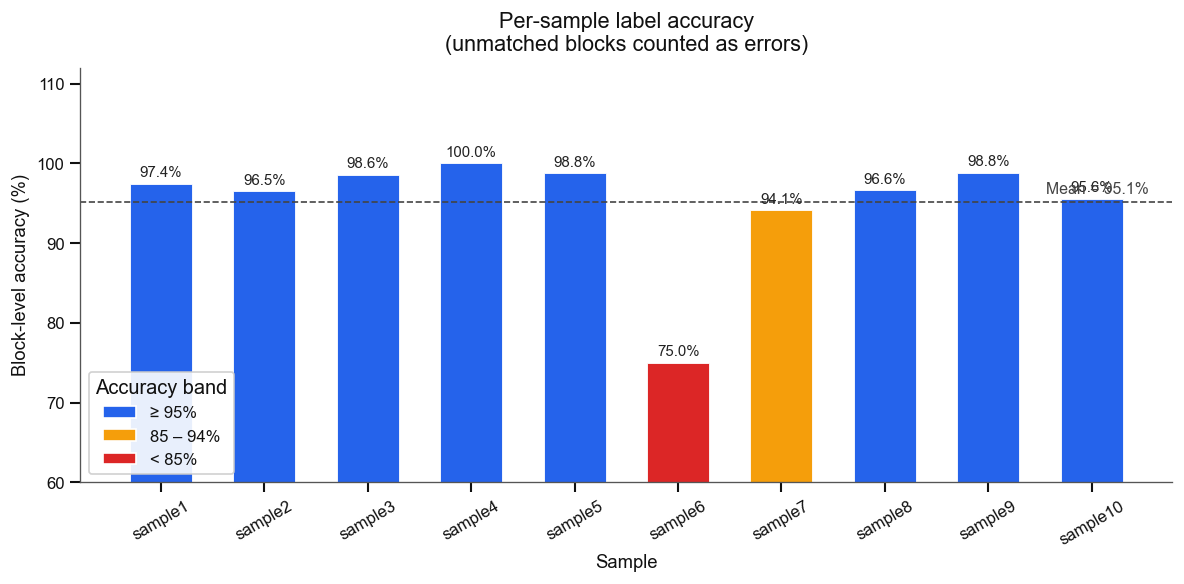

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#2563eb" if a >= 0.95 else "#f59e0b" if a >= 0.85 else "#dc2626"
          for a in df_samples["accuracy"]]

bars = ax.bar(df_samples["sample"], df_samples["accuracy"] * 100,
              color=colors, width=0.6, edgecolor="white", linewidth=0.5)

# Accuracy label above each bar
for bar, acc in zip(bars, df_samples["accuracy"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{acc*100:.1f}%", ha="center", va="bottom", fontsize=9, color="#222222")

# Mean line — annotated at right margin, no legend entry needed
avg = df_samples["accuracy"].mean() * 100
ax.axhline(avg, color="#444444", linestyle="--", linewidth=1.0, zorder=2)
ax.text(len(df_samples) - 0.45, avg + 0.7,
        f"Mean = {avg:.1f}%", ha="right", va="bottom", fontsize=9.5, color="#444444")

ax.set_ylim(60, 112)
ax.set_ylabel("Block-level accuracy (%)")
ax.set_xlabel("Sample")
ax.set_title("Per-sample label accuracy\n(unmatched blocks counted as errors)", pad=10)
ax.tick_params(axis="x", rotation=30)

legend_handles = [
    mpatches.Patch(facecolor="#2563eb", label="≥ 95%"),
    mpatches.Patch(facecolor="#f59e0b", label="85 – 94%"),
    mpatches.Patch(facecolor="#dc2626", label="< 85%"),
]
ax.legend(handles=legend_handles, title="Accuracy band",
          loc="lower left", framealpha=0.9)

sns.despine()
plt.tight_layout()
plt.show()

## 3 — Confusion matrix (all samples combined)

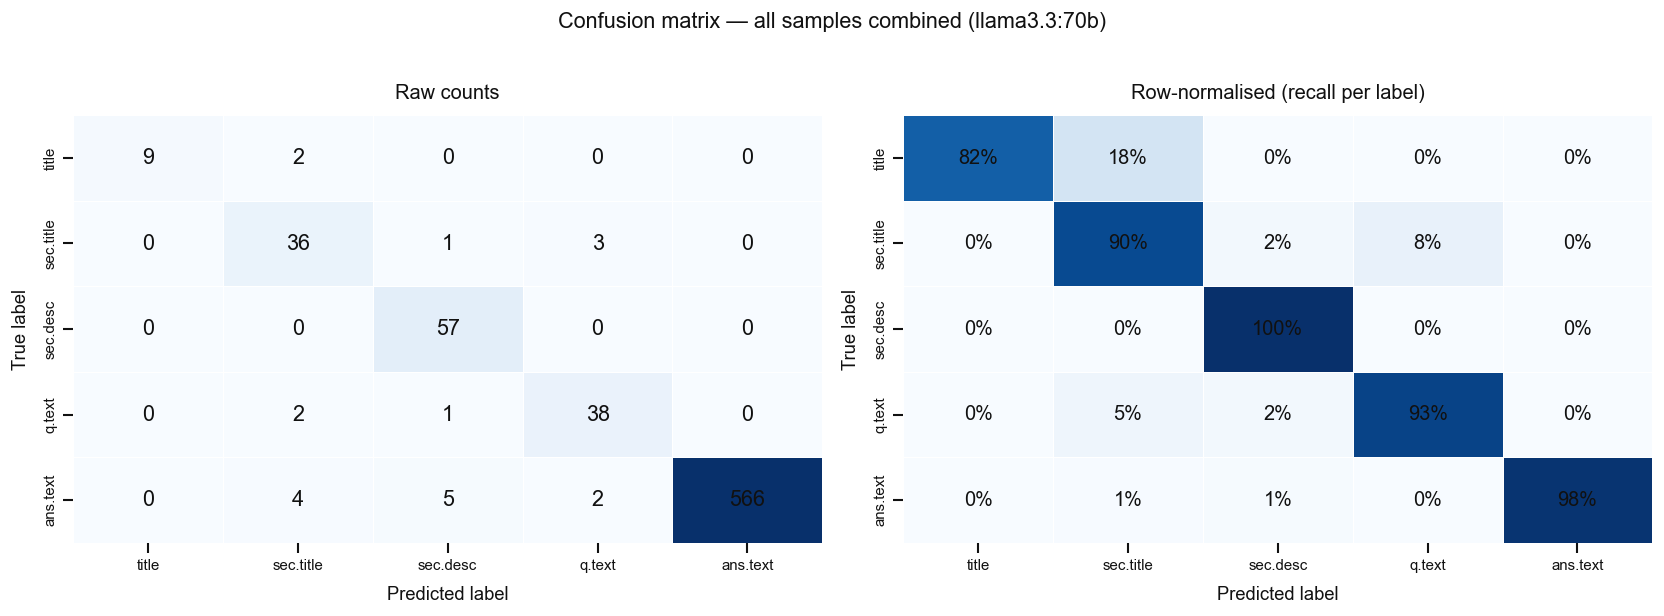

In [5]:
matrix = pd.DataFrame(
    [[total_confusion.get(true, {}).get(pred, 0) for pred in LABELS] for true in LABELS],
    index=SHORT, columns=SHORT
)
matrix_norm = matrix.div(matrix.sum(axis=1).replace(0, 1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", linewidths=0.6,
            linecolor="white", ax=axes[0], cbar=False,
            annot_kws={"size": 13, "color": "#111111"})
axes[0].set_title("Raw counts", pad=10, fontsize=12)
axes[0].set_xlabel("Predicted label", labelpad=8)
axes[0].set_ylabel("True label", labelpad=8)
axes[0].tick_params(labelsize=9)

sns.heatmap(matrix_norm, annot=True, fmt=".0%", cmap="Blues", linewidths=0.6,
            linecolor="white", ax=axes[1], cbar=False, vmin=0, vmax=1,
            annot_kws={"size": 12, "color": "#111111"})
axes[1].set_title("Row-normalised (recall per label)", pad=10, fontsize=12)
axes[1].set_xlabel("Predicted label", labelpad=8)
axes[1].set_ylabel("True label", labelpad=8)
axes[1].tick_params(labelsize=9)

plt.suptitle("Confusion matrix — all samples combined (llama3.3:70b)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4 — Precision / Recall / F1 per label

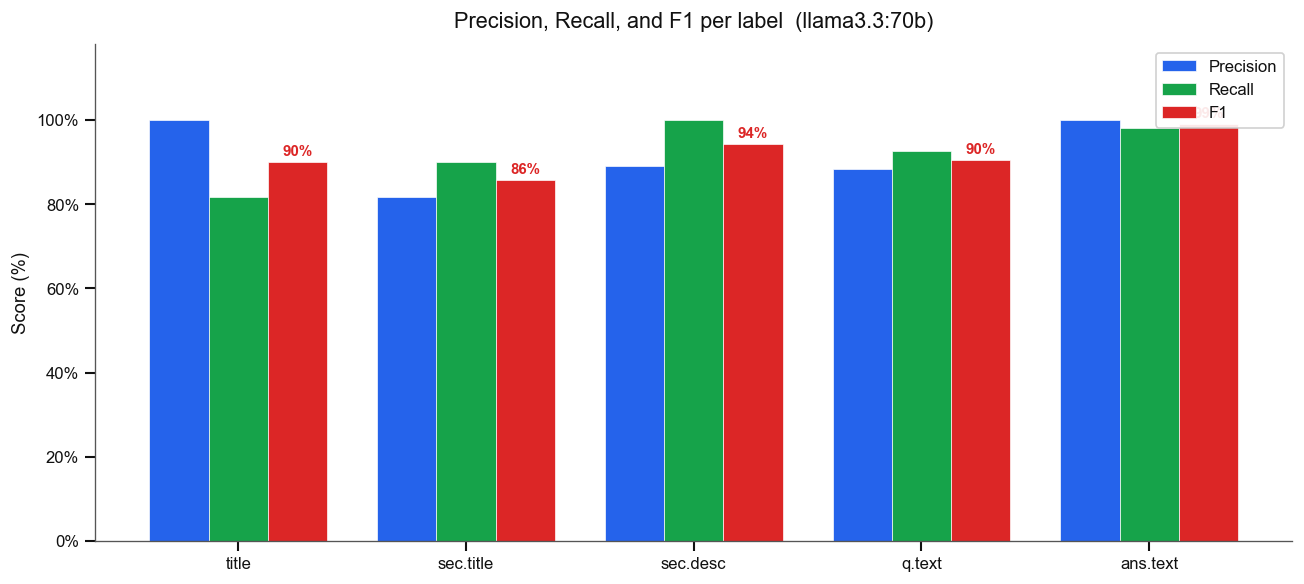

,precision,recall,f1,support
label,,,,
title,100.0%,81.8%,90.0%,11
section.title,81.8%,90.0%,85.7%,40
section.description,89.1%,100.0%,94.2%,57
question.text,88.4%,92.7%,90.5%,41
answer.text,100.0%,98.1%,99.0%,577


In [6]:
rows = []
for lbl in LABELS:
    tp = total_confusion.get(lbl, {}).get(lbl, 0)
    fp = sum(total_confusion.get(other, {}).get(lbl, 0) for other in LABELS if other != lbl)
    fn = sum(v for pred, v in total_confusion.get(lbl, {}).items() if pred != lbl)
    support = tp + fn
    p  = tp / (tp + fp) if (tp + fp) else 0.0
    r  = tp / support   if support   else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) else 0.0
    rows.append({"label": lbl, "precision": p, "recall": r, "f1": f1, "support": support})

df_f1 = pd.DataFrame(rows)

x = range(len(LABELS))
w = 0.26

fig, ax = plt.subplots(figsize=(11, 5))

b1 = ax.bar([i - w for i in x], df_f1["precision"] * 100, width=w,
            label="Precision", color="#2563eb", edgecolor="white", linewidth=0.4)
b2 = ax.bar([i     for i in x], df_f1["recall"]    * 100, width=w,
            label="Recall",    color="#16a34a", edgecolor="white", linewidth=0.4)
b3 = ax.bar([i + w for i in x], df_f1["f1"]        * 100, width=w,
            label="F1",        color="#dc2626", edgecolor="white", linewidth=0.4)

# Label only the F1 bars to keep the chart readable
for bar, row in zip(b3, df_f1.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f"{row.f1*100:.0f}%", ha="center", va="bottom",
            fontsize=9, fontweight="bold", color="#dc2626")

ax.set_xticks(list(x))
ax.set_xticklabels(SHORT, fontsize=10)
ax.set_ylim(0, 118)
ax.set_ylabel("Score (%)")
ax.set_title("Precision, Recall, and F1 per label  (llama3.3:70b)", pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.legend(loc="upper right", framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

df_f1.set_index("label").style.format({
    "precision": "{:.1%}", "recall": "{:.1%}", "f1": "{:.1%}", "support": "{:.0f}"
})

## 5 — Mislabeled blocks: what went wrong?

In [7]:
if df_errors.empty:
    print("No errors — perfect score!")
else:
    print(f"{len(df_errors)} mislabeled blocks\n")
    # Error breakdown by true → pred
    breakdown = df_errors.groupby(["true", "pred"]).size().reset_index(name="count").sort_values("count", ascending=False)
    print(breakdown.to_string(index=False))

23 mislabeled blocks

         true                pred  count
  answer.text section.description      5
  answer.text       section.title      4
     no_match       section.title      3
section.title       question.text      3
  answer.text       question.text      2
        title       section.title      2
question.text       section.title      2
question.text section.description      1
section.title section.description      1


In [8]:
# Show the actual mislabeled text
if not df_errors.empty:
    pd.set_option("display.max_colwidth", 100)
    df_errors[["sample", "page", "true", "pred", "text"]]

## 6 — Zoom in on a specific error type

Edit the filter below to inspect any confusion pair.

In [9]:
# Change these to inspect a different confusion pair
TRUE_LABEL = "question.text"
PRED_LABEL = "section.description"

subset = df_errors[(df_errors["true"] == TRUE_LABEL) & (df_errors["pred"] == PRED_LABEL)]
print(f"Blocks labeled '{PRED_LABEL}' that should be '{TRUE_LABEL}': {len(subset)}\n")
for _, row in subset.iterrows():
    print(f"  [{row['sample']} p.{row['page']}]  {row['text']}")
    print()

Blocks labeled 'section.description' that should be 'question.text': 1

  [sample2 p.2]  This should include, where appropriate:



## 7 — Model comparison: llama3.3:70b vs llama3.1:8b

In [10]:
MODELS = {
    "llama3.3:70b": "llama3.3-70b",
    "llama3.1:8b":  "llama3.1-8b",
}
COLORS = {
    "llama3.3:70b": "#60a5fa",
    "llama3.1:8b":  "#f472b6",
}

model_sample_rows = {}
model_confusion   = {}

for model_name, model_tag in MODELS.items():
    sample_rows = []
    total_conf  = defaultdict(lambda: defaultdict(int))

    for manual_path in samples:
        stem      = manual_path.stem.replace("_dmp", "")
        pred_path = LLM_DIR / f"{stem}_{model_tag}.json"
        if not pred_path.exists():
            continue

        gold      = extract_gold(manual_path)
        confusion = evaluate_sample(pred_path, gold)

        tp     = sum(confusion.get(l, {}).get(l, 0) for l in LABELS)
        n      = sum(sum(v.values()) for v in confusion.values())
        errors = n - tp
        sample_rows.append({
            "sample":   stem,
            "total":    n,
            "correct":  tp,
            "errors":   errors,
            "accuracy": tp / n if n else 0,
            "formula":  f"{tp}/{n}",
        })
        for true_lbl, preds in confusion.items():
            for pred_lbl, cnt in preds.items():
                total_conf[true_lbl][pred_lbl] += cnt

    model_sample_rows[model_name] = pd.DataFrame(sample_rows)
    model_confusion[model_name]   = total_conf

# Comparison table
header = f"{'Sample':<12}  {'llama3.3:70b':>14}  {'Correct':>7}  {'Errors':>6}  ||  {'llama3.1:8b':>12}  {'Correct':>7}  {'Errors':>6}  {'Diff':>7}"
print(header)
print("-" * len(header))

df70 = model_sample_rows["llama3.3:70b"]
df8  = model_sample_rows["llama3.1:8b"]

for _, r70 in df70.iterrows():
    r8   = df8[df8["sample"] == r70["sample"]].iloc[0]
    diff = r8["accuracy"] - r70["accuracy"]
    sign = "+" if diff >= 0 else ""
    print(
        f"{r70['sample']:<12}  {r70['accuracy']*100:>13.1f}%  {int(r70['correct']):>7}  {int(r70['errors']):>6}"
        f"  ||  {r8['accuracy']*100:>11.1f}%  {int(r8['correct']):>7}  {int(r8['errors']):>6}  {sign}{diff*100:>5.1f}%"
    )

print("-" * len(header))
ov70 = df70["correct"].sum() / df70["total"].sum()
ov8  = df8["correct"].sum()  / df8["total"].sum()
diff = ov8 - ov70
sign = "+" if diff >= 0 else ""
tn70, tc70 = int(df70["total"].sum()), int(df70["correct"].sum())
tn8,  tc8  = int(df8["total"].sum()),  int(df8["correct"].sum())
print(
    f"{'TOTAL':<12}  {ov70*100:>13.1f}%  {tc70:>7}  {tn70-tc70:>6}"
    f"  ||  {ov8*100:>11.1f}%  {tc8:>7}  {tn8-tc8:>6}  {sign}{diff*100:>5.1f}%"
)

Sample          llama3.3:70b  Correct  Errors  ||   llama3.1:8b  Correct  Errors     Diff
-----------------------------------------------------------------------------------------
sample1                97.4%       76       2  ||         82.1%       64      14  -15.4%
sample2                96.5%      165       6  ||         62.6%      107      64  -33.9%
sample3                98.6%       68       1  ||         81.2%       56      13  -17.4%
sample4               100.0%       78       0  ||         65.4%       51      27  -34.6%
sample5                98.8%       79       1  ||         67.5%       54      26  -31.2%
sample6                75.0%       18       6  ||         66.7%       16       8   -8.3%
sample7                94.1%       16       1  ||         82.4%       14       3  -11.8%
sample8                96.6%       57       2  ||         69.5%       41      18  -27.1%
sample9                98.8%       84       1  ||         61.2%       52      33  -37.6%
sample10           

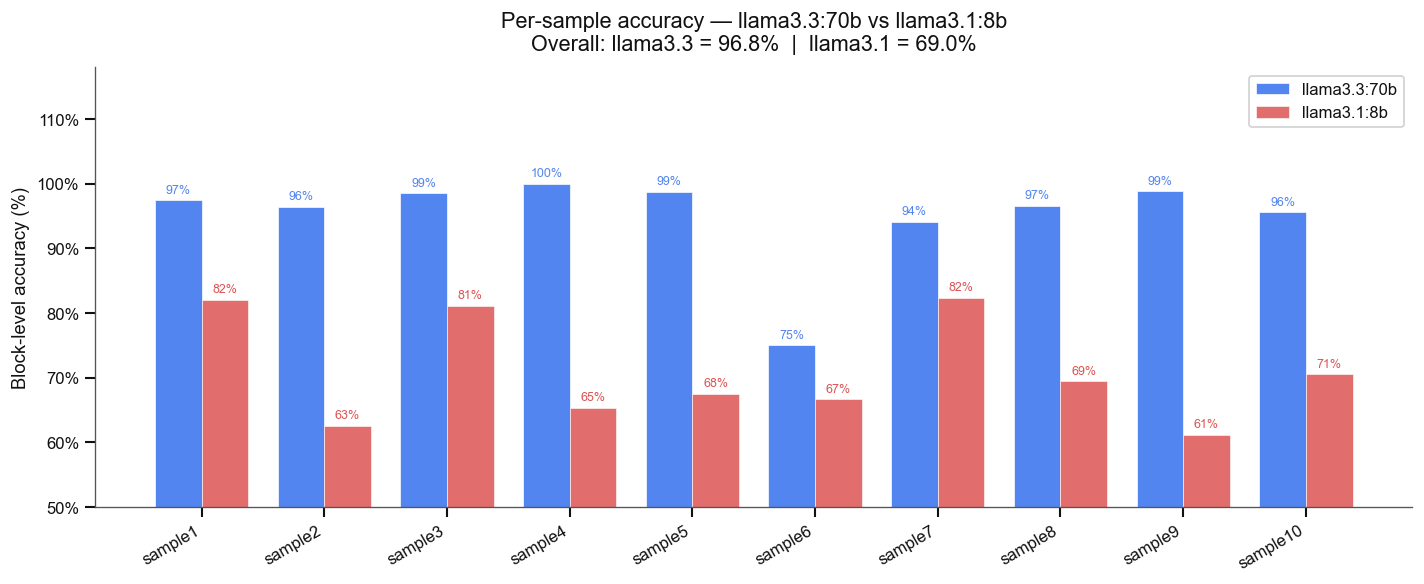

In [23]:
# Sort both DataFrames numerically (sample1 → sample10)
df70 = model_sample_rows["llama3.3:70b"]
df8  = model_sample_rows["llama3.1:8b"]

x_labels = sorted(df70["sample"].tolist(), key=_snum)
df70_s   = df70.set_index("sample").loc[x_labels].reset_index()
df8_s    = df8.set_index("sample").loc[x_labels].reset_index()

x     = range(len(x_labels))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5))

bars70 = ax.bar([xi - width/2 for xi in x], df70_s["accuracy"] * 100,
                width=width, label="llama3.3:70b",
                color="#5385f1", edgecolor="white", linewidth=0.4)
bars8  = ax.bar([xi + width/2 for xi in x], df8_s["accuracy"]  * 100,
                width=width, label="llama3.1:8b",
                color="#dd5454", edgecolor="white", linewidth=0.4, alpha=0.85)

for bar in bars70:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.6,
            f"{bar.get_height():.0f}%", ha="center", va="bottom",
            fontsize=7.5, color="#5385f1")
for bar in bars8:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.6,
            f"{bar.get_height():.0f}%", ha="center", va="bottom",
            fontsize=7.5, color="#dd5454")

ov70 = df70["correct"].sum() / df70["total"].sum()
ov8  = df8["correct"].sum()  / df8["total"].sum()

ax.set_xticks(list(x))
ax.set_xticklabels(x_labels, rotation=30, ha="right", fontsize=10)
ax.set_ylim(50, 118)
ax.set_ylabel("Block-level accuracy (%)")
ax.set_title(
    "Per-sample accuracy — llama3.3:70b vs llama3.1:8b\n"
    f"Overall: llama3.3 = {ov70*100:.1f}%  |  llama3.1 = {ov8*100:.1f}%",
    pad=10,
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.legend(loc="upper right", framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

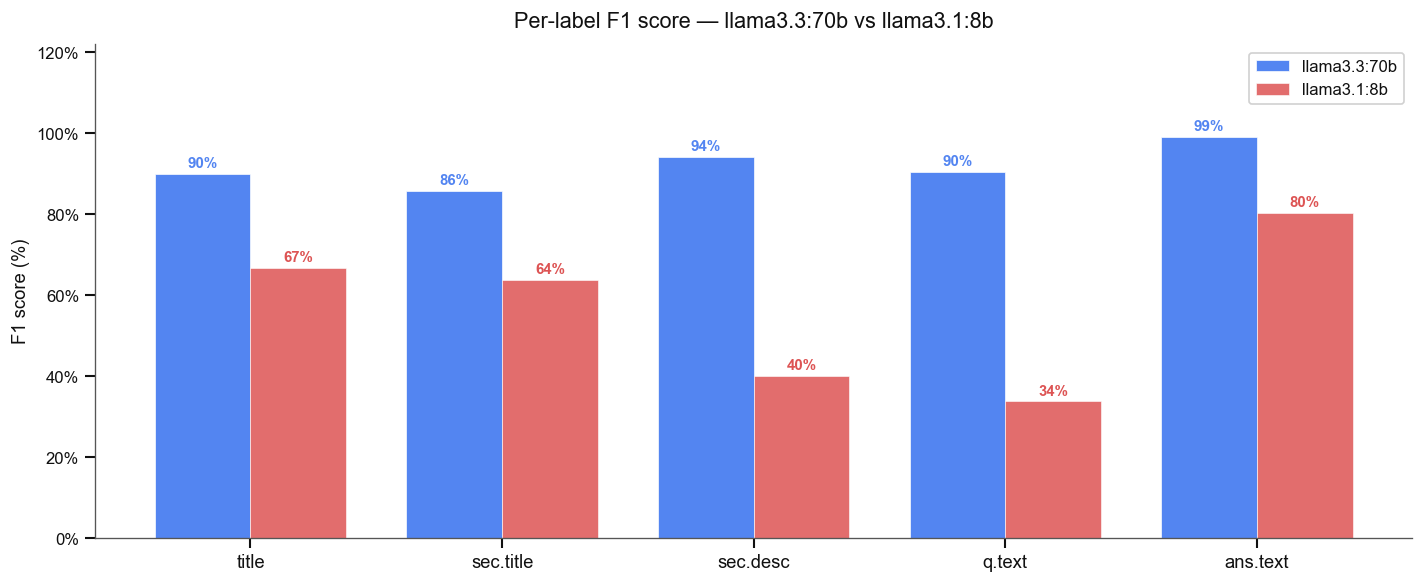


Label                    llama3.3 F1   llama3.1 F1      Diff
--------------------------------------------------------------
title                          90.0%         66.7%   -23.3%
section.title                  85.7%         63.9%   -21.8%
section.description            94.2%         40.0%   -54.2%
question.text                  90.5%         33.8%   -56.7%
answer.text                    99.0%         80.2%   -18.8%


In [24]:
def compute_f1_rows(confusion):
    rows = []
    for lbl in LABELS:
        tp = confusion.get(lbl, {}).get(lbl, 0)
        fp = sum(confusion.get(o, {}).get(lbl, 0) for o in LABELS if o != lbl)
        fn = sum(v for p, v in confusion.get(lbl, {}).items() if p != lbl)
        p  = tp / (tp + fp) if (tp + fp) else 0.0
        r  = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * p * r / (p + r) if (p + r) else 0.0
        rows.append({"label": lbl, "precision": p, "recall": r, "f1": f1})
    return pd.DataFrame(rows)

f1_by_model = {m: compute_f1_rows(model_confusion[m]) for m in MODELS}

MODEL_COLORS = {"llama3.3:70b": "#5385f1", "llama3.1:8b": "#dd5454"}
x     = range(len(LABELS))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5))

for i, (model_name, df_f1_m) in enumerate(f1_by_model.items()):
    color  = MODEL_COLORS[model_name]
    offset = (i - 0.5) * width
    bars   = ax.bar([xi + offset for xi in x], df_f1_m["f1"] * 100,
                    width=width, label=model_name, color=color,
                    edgecolor="white", linewidth=0.4,
                    alpha=1.0 if i == 0 else 0.85)
    for bar, row in zip(bars, df_f1_m.itertuples()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f"{row.f1*100:.0f}%", ha="center", va="bottom",
                fontsize=9, fontweight="bold", color=color)

ax.set_xticks(list(x))
ax.set_xticklabels(SHORT, fontsize=11)
ax.set_ylim(0, 122)
ax.set_ylabel("F1 score (%)")
ax.set_title("Per-label F1 score — llama3.3:70b vs llama3.1:8b", pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.legend(loc="upper right", framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

print(f"\n{'Label':<22}  {'llama3.3 F1':>12}  {'llama3.1 F1':>12}  {'Diff':>8}")
print("-" * 62)
df70f1 = f1_by_model["llama3.3:70b"]
df8f1  = f1_by_model["llama3.1:8b"]
for lbl, r70, r8 in zip(LABELS, df70f1.itertuples(), df8f1.itertuples()):
    diff = r8.f1 - r70.f1
    sign = "+" if diff >= 0 else ""
    print(f"{lbl:<22}  {r70.f1*100:>11.1f}%  {r8.f1*100:>11.1f}%  {sign}{diff*100:>6.1f}%")

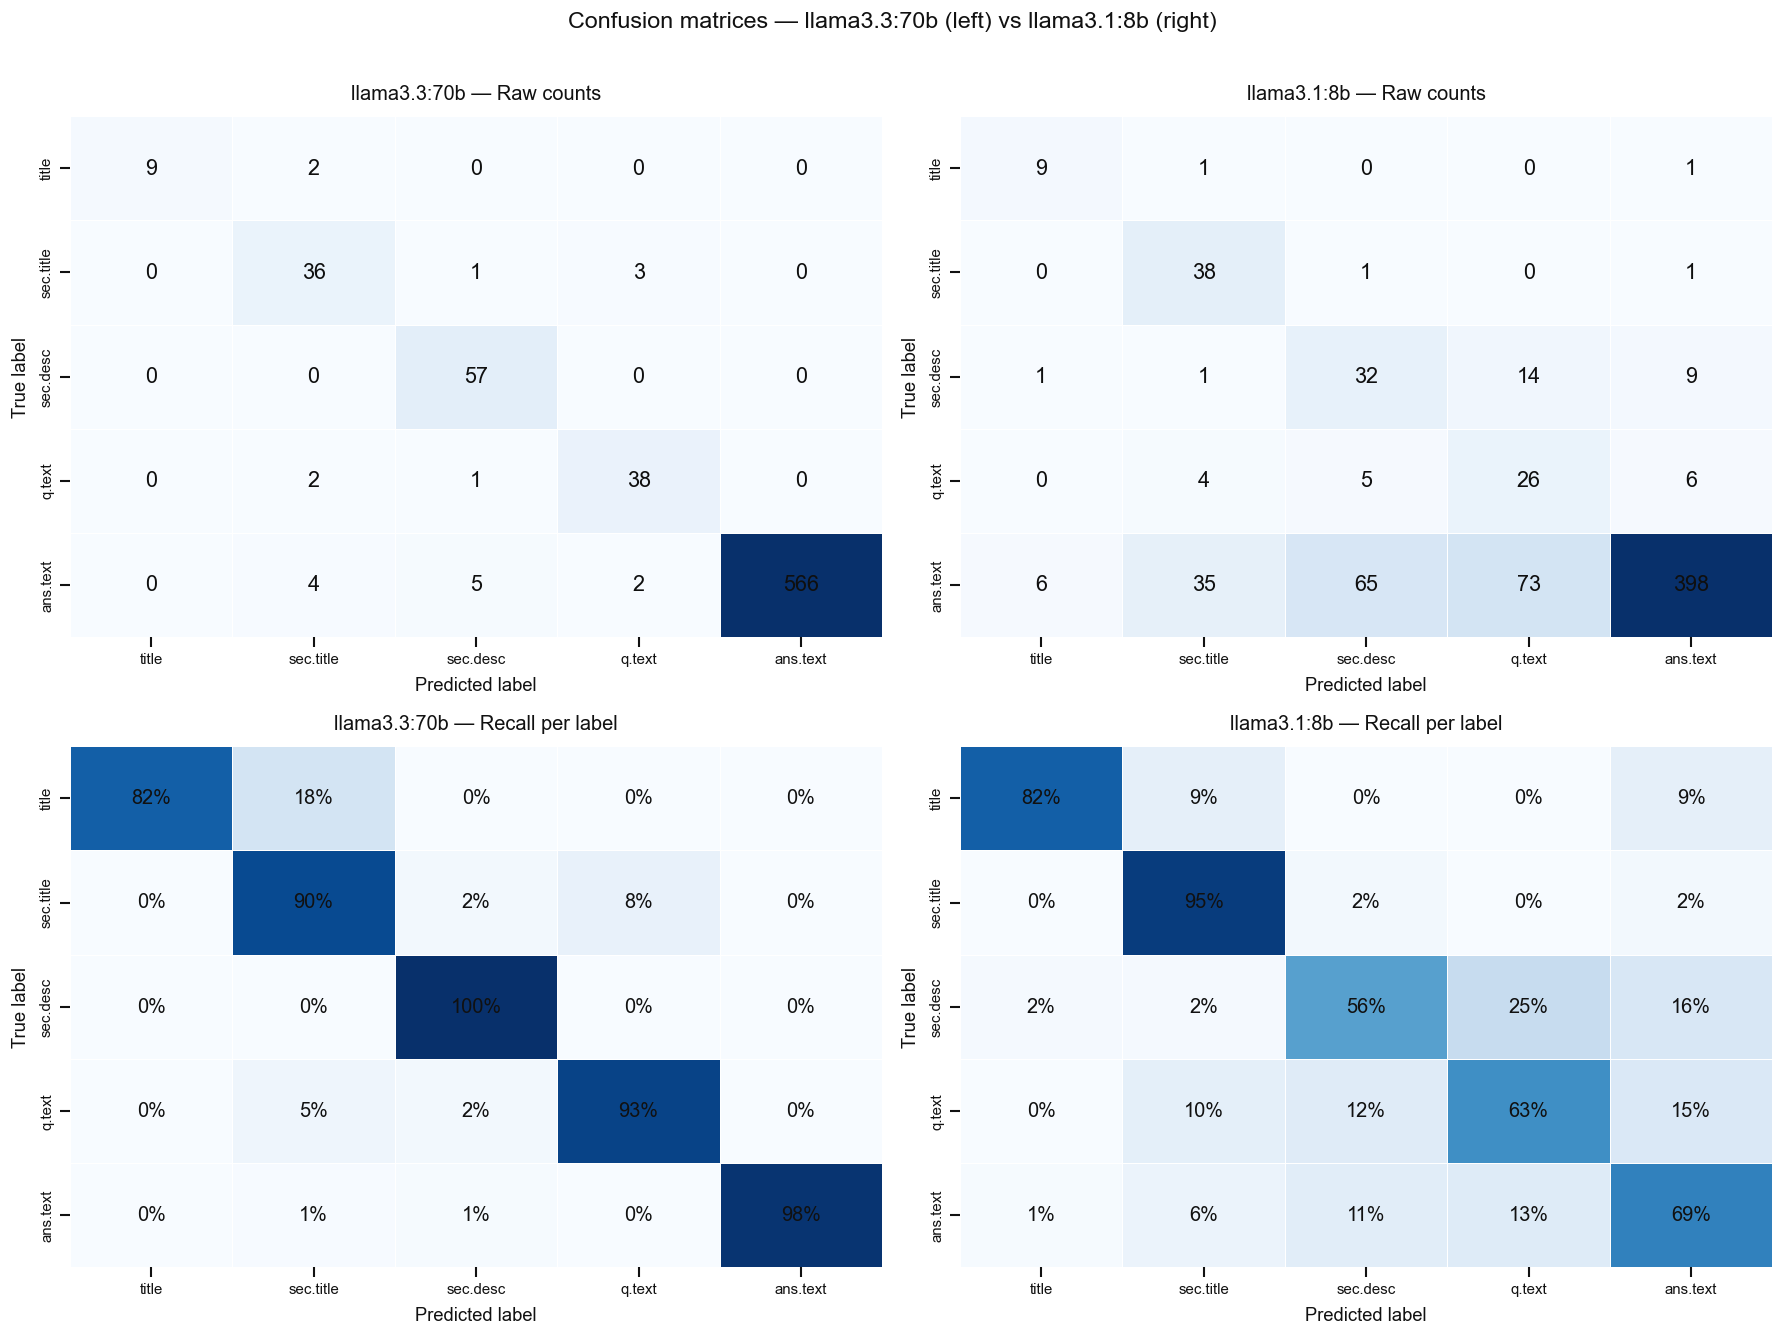

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for col, (model_name, conf) in enumerate(model_confusion.items()):
    matrix = pd.DataFrame(
        [[conf.get(true, {}).get(pred, 0) for pred in LABELS] for true in LABELS],
        index=SHORT, columns=SHORT,
    )
    matrix_norm = matrix.div(matrix.sum(axis=1).replace(0, 1), axis=0)

    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", linewidths=0.6,
                linecolor="white", ax=axes[0][col], cbar=False,
                annot_kws={"size": 13, "color": "#0F0F0F"})
    axes[0][col].set_title(f"{model_name} — Raw counts", pad=10, fontsize=12)
    axes[0][col].set_xlabel("Predicted label", labelpad=6)
    axes[0][col].set_ylabel("True label", labelpad=6)
    axes[0][col].tick_params(labelsize=9)

    sns.heatmap(matrix_norm, annot=True, fmt=".0%", cmap="Blues", linewidths=0.6,
                linecolor="white", ax=axes[1][col], cbar=False, vmin=0, vmax=1,
                annot_kws={"size": 12, "color": "#111111"})
    axes[1][col].set_title(f"{model_name} — Recall per label", pad=10, fontsize=12)
    axes[1][col].set_xlabel("Predicted label", labelpad=6)
    axes[1][col].set_ylabel("True label", labelpad=6)
    axes[1][col].tick_params(labelsize=9)

plt.suptitle(
    "Confusion matrices — llama3.3:70b (left) vs llama3.1:8b (right)",
    fontsize=14, y=1.01,
)
plt.tight_layout()
plt.show()